# MTG visual-family and duplicate audit

This notebook reproduces the decision metrics from the read-only audit of the released 111,131-row Magic scanner catalog, the pinned 2026-08-27 Scryfall bulk snapshot, and the released int8 vector index. It distinguishes catalog reprints and reused illustrations from actual duplicate image defects.

In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd()
audit_path = root / '.artifacts/mtg-visual-family-audit-2026-08-28.json'
assert audit_path.exists(), f'Missing audit output: {audit_path}'
audit = json.loads(audit_path.read_text())
audit['status'], audit['inputs']['metadata']['rows']

('needs-review', 111131)

In [2]:
released = audit['inputs']['metadata']['rows']
quality = audit['quality']
leakage = audit['splitLeakage']
similarity = audit['vectors']['sameIllustrationSimilarity']
collisions = audit['vectors']['exactQ8VectorCollisions']

metrics = pd.DataFrame([
    ('Rows in repeated Oracle families', quality['oracleId']['affectedRows'], released),
    ('Rows in reused illustration families', quality['illustrationId']['affectedRows'], released),
    ('Reused-art eval rows with a train twin', leakage['evaluationRowsWithTrainIllustrationTwin'], leakage['evaluationRows']),
    ('Reused-art rows with cosine twin ≥ 0.95', similarity['rowsWithNearestTwinAtOrAbove095'], similarity['rowsWithRepeatedIllustration']),
], columns=['metric', 'numerator', 'denominator'])
metrics['rate'] = metrics['numerator'] / metrics['denominator']
metrics

,metric,numerator,denominator,rate
0,Rows in repeated Oracle families,95699,111131,0.861137
1,Rows in reused illustration families,80420,111131,0.723650
2,Reused-art eval rows with a train twin,7735,7955,0.972344
3,Reused-art rows with cosine twin ≥ 0.95,23234,80420,0.288908


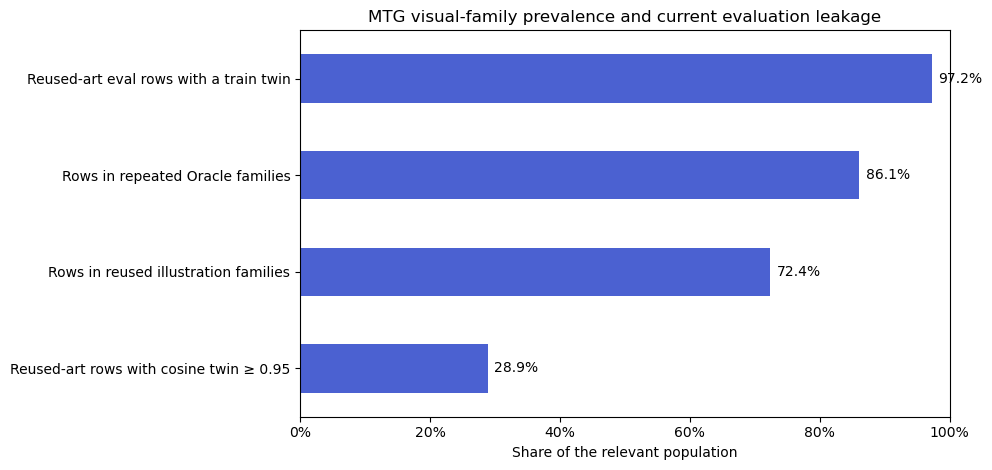

In [3]:
ax = metrics.sort_values('rate').plot.barh(
    x='metric', y='rate', legend=False, color='#4B61D1', figsize=(10, 4.8)
)
ax.set_title('MTG visual-family prevalence and current evaluation leakage')
ax.set_xlabel('Share of the relevant population')
ax.set_ylabel('')
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
for patch, value in zip(ax.patches, metrics.sort_values('rate')['rate']):
    ax.text(value + 0.01, patch.get_y() + patch.get_height()/2, f'{value:.1%}', va='center')
plt.tight_layout()
plt.show()

In [4]:
checks = {
    'all released rows matched current Scryfall': audit['catalogJoin']['matchedRows'] == released,
    'no duplicate runtime rows': quality['exactRuntimeDuplicateGroups'] == 0,
    'no duplicate canonical image URLs': quality['canonicalImageURL']['repeatedGroups'] == 0,
    'released index has no zero vectors': audit['vectors']['zeroVectors'] == 0,
    'generic Art Series backs are present': collisions['artSeriesBackRows'] == 1302,
    'current source contains new eligible rows': audit['catalogJoin']['newCurrentSourceRows'] == 903,
}
assert all(checks.values()), checks
pd.Series(checks, name='passed')

all released rows matched current Scryfall    True
no duplicate runtime rows                     True
no duplicate canonical image URLs             True
released index has no zero vectors            True
generic Art Series backs are present          True
current source contains new eligible rows     True
Name: passed, dtype: bool

## Interpretation

The catalog is not accidentally duplicating runtime records or image URLs. Reprints and same-art printings are legitimate catalog entries and must remain separate for collection identity. The defect is representational: non-identifying reverse faces and near-identical printings are being treated as independent recognition classes, while same-illustration rows are partitioned across training and evaluation. This makes the catalog-only evaluation optimistic and gives an ArcFace objective contradictory labels for images that are visually indistinguishable.